In [1]:
import os

# in the case of a workstation with multiple GPU devices
# we can select only one of them for use in this notebook
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Variational Autoencoder with a Normalizing Flow prior

Using a normalizing flow as prior for the latent variables instead of the typical standard Gaussian is an easy way to make a variational autoencoder (VAE) more expressive. This notebook demonstrates how to implement a VAE with a normalizing flow as prior for the MNIST dataset. We strongly recommend to read [Pyro's VAE tutorial](vae.ipynb) first.

> In this notebook we use [Zuko](https://zuko.readthedocs.io/) to implement normalizing flows, but similar results can be obtained with other PyTorch-based flow libraries.

In [2]:
import pyro
import torch
import torch.nn as nn
import torch.utils.data as data
import zuko

from pyro.contrib.zuko import ZukoToPyro
from pyro.optim import AdamW
from pyro.infer import SVI, Trace_ELBO
from torch import Tensor
from torchvision.datasets import MNIST
from torchvision.transforms.functional import to_tensor, to_pil_image
from torch.nn.functional import relu, sigmoid, softplus, grid_sample, affine_grid, one_hot, softmax
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context='notebook', style='dark', palette='deep', font='sans-serif', font_scale=1, color_codes=True)
plt.style.use('dark_background')

## Data

The [MNIST](https://wikipedia.org/wiki/MNIST_database) dataset consists of 28 x 28 grayscale images representing handwritten digits (0 to 9).

In [3]:
trainset = MNIST(root='data', download=True, train=True, transform=to_tensor)
testset = MNIST(root='data', download=True, train=False, transform=to_tensor)
trainloader = data.DataLoader(trainset, batch_size=256, shuffle=True)
testloader = data.DataLoader(testset, batch_size=len(testset), shuffle=True)

In [4]:
x = [trainset[i][0] for i in range(16)]
x = torch.cat(x, dim=-1)

to_pil_image(x)

## Model

As for the [previous tutorial](vae.ipynb), we choose a (diagonal) Gaussian model as encoder $q_\psi(z | x)$ and a Bernoulli model as decoder $p_\phi(x | z)$. 

In [5]:
class GaussianEncoder(nn.Module):
    def __init__(self, features: int, latent: int, hidden: int = 1024):
        super().__init__()

        self.hyper = nn.Sequential(
            nn.Linear(features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * latent),
        )

    def forward(self, x: Tensor):
        phi = self.hyper(x)
        mu, log_sigma = phi.chunk(2, dim=-1)

        return pyro.distributions.Normal(mu, log_sigma.exp()).to_event(1)


class ProbDecoder(nn.Module):
    def __init__(self, features: int, latent: int):
        super().__init__()

        self.hyper = nn.Sequential(
            nn.Linear(latent, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, features),
        )

    def forward(self, z: Tensor):
        phi = self.hyper(z)
        return torch.sigmoid(phi)

However, we choose a [masked autoregressive flow](https://arxiv.org/abs/1705.07057) (MAF) as prior $p_\phi(z)$ instead of the typical standard Gaussian $\mathcal{N}(0, I)$. Instead of implementing the MAF ourselves, we borrow it from the [Zuko](https://github.com/probabilists/zuko) library. Because Zuko distributions are very similar to Pyro distributions, a thin wrapper (`ZukoToPyro`) is sufficient to make Zuko and Pyro 100% compatible.

In [6]:
z_where_prior_loc = torch.tensor([1., 0., 0., 0.]).cuda()
z_where_prior_scale = torch.tensor([0.1, 1., 1., 1.]).cuda()
q_scale = torch.tensor([-2., -2., 2., -2.]).cuda()
select_indices = torch.LongTensor([1, 0, 0, 1]).cuda()

def get_test_accuracy(svi, cutoff=1000):
    log_evidence = []
    for x, l in testloader:
        x = x.flatten(-3).cuda()
        for c in one_hot(torch.arange(10), 10).cuda():
            log_margs = []
            for xc in x[:cutoff]:
                log_margs.append(- svi.evaluate_loss(xc[None], c[None]))
            log_evidence.append(torch.tensor(log_margs))

    prob = softmax(torch.stack(log_evidence, dim=-1), dim=-1)
    return (prob.argmax(-1) == l[:cutoff]).cpu().numpy().mean()

def map_to_sR(q):
    n, k = q.shape
    s = torch.sum(q ** 2, -1, keepdims=True)

    qs = q * q[..., -1:]
    Q = (qs[:, select_indices] * q_scale).view(n, k, k)
    return torch.diag_embed(torch.tile(s, (1, 2))) + Q

def expand_z_where(z_where):
    # Takes 3-dimensional vectors, and massages them into 2x3 matrices with elements like so:
    # [q1, q2 x,y] -> [[s+q11,q12,x], [q21,s + q22,y]] where q11=q22= -2q2^2, q12 = -q21 = -2q1q2.
    n = z_where.size(0)
    sR = map_to_sR(z_where[..., :2])
    return torch.cat((sR, z_where[..., 2:][..., None]), -1)

def object_to_image(z_where, obj, img_size=28, obj_size=28):
    n = obj.size(0)
    theta = expand_z_where(z_where)
    grid = affine_grid(theta, torch.Size((n, 1, img_size, img_size)), align_corners=False)
    out = grid_sample(obj.view(n, 1, obj_size, obj_size), grid, align_corners=False)
    return out.view(n, img_size, img_size)

class VAE(nn.Module):
    def __init__(self, features: int, latent: int = 16, context: int = 0, conditional_posterior: bool = True):
        super().__init__()

        input_dim = features + context if conditional_posterior else features
        self.encoder = GaussianEncoder(input_dim, latent)
        self.decoder = ProbDecoder(features, latent)

        self.prior = zuko.flows.MAF(
            features=latent,
            context=context,
            transforms=3,
            hidden_features=(256, 256),
        )

        self.conditional_posterior = conditional_posterior

    def model(self, x: Tensor, context: Tensor):
        n = len(x)
        pyro.module("prior", self.prior)
        pyro.module("decoder", self.decoder)

        with pyro.plate("batch", n):
            # p(z|c)
            z = pyro.sample("z", ZukoToPyro(self.prior(context)))
            rho = self.decoder(z)
            sd = 0.25 * torch.ones_like(x)
            # p(x|z) = N(mu(z), sigma^2)
            pyro.sample('obs', pyro.distributions.Normal(rho, sd).to_event(1), obs=x)

    def guide(self, x: Tensor, context: Tensor):
        # q(z|c, x)
        pyro.module("encoder", self.encoder)

        with pyro.plate("batch", len(x)):
            inp = torch.cat([x, context], dim=-1) if self.conditional_posterior else x
            z1 = pyro.sample("z", self.encoder(inp))

class VAEST(nn.Module):
    def __init__(self, features: int, latent: int = 16, context: int = 0, conditional_posterior: bool = True):
        super().__init__()
        
        input_dim = features + context if conditional_posterior else features
        self.encoder_what = GaussianEncoder(input_dim, latent)
        self.encoder_where = GaussianEncoder(input_dim, 4)
        self.decoder = ProbDecoder(features, latent)

        self.prior = zuko.flows.MAF(
            features=latent,
            context=context,
            transforms=3,
            hidden_features=(256, 256),
        )

        self.conditional_posterior = conditional_posterior

    def model(self, x: Tensor, context: Tensor):
        n = len(x)
        pyro.module("prior", self.prior)
        pyro.module("decoder", self.decoder)

        with pyro.plate("batch", n):
            z_where = pyro.sample('z_where', pyro.distributions.Normal(z_where_prior_loc, z_where_prior_scale).to_event(1))
            z = pyro.sample("z", ZukoToPyro(self.prior(context)))
            rho = self.decoder(z)
            y = object_to_image(z_where, rho).view(n, -1)
            sd = 0.25 * torch.ones_like(x)
            pyro.sample('obs', pyro.distributions.Normal(y, sd).to_event(1), obs=x)

    def guide(self, x: Tensor, context: Tensor):
        pyro.module("encoder_z", self.encoder_what)
        pyro.module("encoder_w", self.encoder_where)

        with pyro.plate("batch", len(x)):
            inp = torch.cat([x, context], dim=-1) if self.conditional_posterior else x
            z1 = pyro.sample("z", self.encoder_what(inp))
            z2 = pyro.sample("z_where", self.encoder_where(inp))

vae1 = VAE(784, 16, context=10).cuda()
vae2 = VAE(784, 16, context=10, conditional_posterior=False).cuda()
vae3 = VAEST(784, 16, context=10).cuda()
vae4 = VAEST(784, 16, context=10, conditional_posterior=False).cuda()

## Training

We train our VAE with a standard stochastic variational inference (SVI) pipeline. We first investigate the standard setup without spatial transform prior.

100%|██████████| 100/100 [10:25<00:00,  6.26s/it, loss=304]


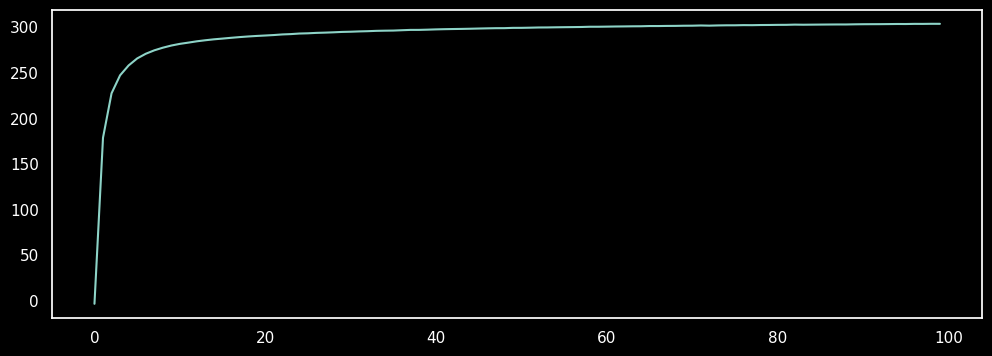

In [7]:
pyro.clear_param_store()

svi = SVI(vae1.model, vae1.guide, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

elbo = []
for epoch in (bar := tqdm(range(100))):
    losses = []

    for x, l in trainloader:
        x = x.flatten(-3).cuda()
        context = one_hot(l, 10).cuda()

        losses.append(svi.step(x, context))

    losses = torch.tensor(losses)
    elbo.append( - losses.sum().item() / len(trainset))
    bar.set_postfix(loss=elbo[-1])

plt.figure(figsize=(12, 4))
plt.plot(elbo)

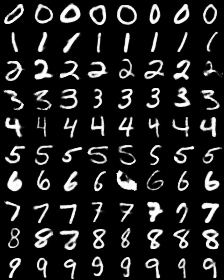

In [8]:
xs = []
for c in one_hot(torch.arange(10), 10):
    z = vae1.prior(c.cuda()).sample((8,))
    x = vae1.decoder(z).reshape(-1, 28, 28)
    xs.append(x)

xs = torch.stack(xs)

to_pil_image(xs.movedim(1, 2).reshape(28 * 10, -1))

In [22]:
get_test_accuracy(svi, cutoff=10_000)

np.float64(0.9576)

Now lets test if the classification accuracy when amortized posterior does not depend on class label.

In [ ]:
pyro.clear_param_store()

svi2 = SVI(vae2.model, vae2.guide, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

elbo = []
for epoch in (bar := tqdm(range(100))):
    losses = []

    for x, l in trainloader:
        x = x.flatten(-3).cuda()
        context = one_hot(l, 10).cuda()

        losses.append(svi2.step(x, context))

    losses = torch.tensor(losses)
    elbo.append( - losses.sum().item() / len(trainset))
    bar.set_postfix(loss=elbo[-1])

plt.figure(figsize=(12, 4))
plt.plot(elbo)

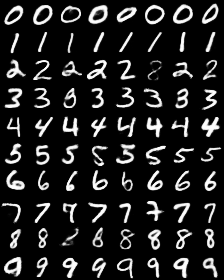

In [11]:
xs = []
for c in one_hot(torch.arange(10), 10):
    z = vae2.prior(c.cuda()).sample((8,))
    x = vae2.decoder(z).reshape(-1, 28, 28)
    xs.append(x)

xs = torch.stack(xs)

to_pil_image(xs.movedim(1, 2).reshape(28 * 10, -1))

In [21]:
get_test_accuracy(svi2, cutoff=10_000)

np.float64(0.9146)

Now lets test VAE with spatial transformation latents and normalizing flow priors.

100%|██████████| 100/100 [11:36<00:00,  6.97s/it, loss=284]


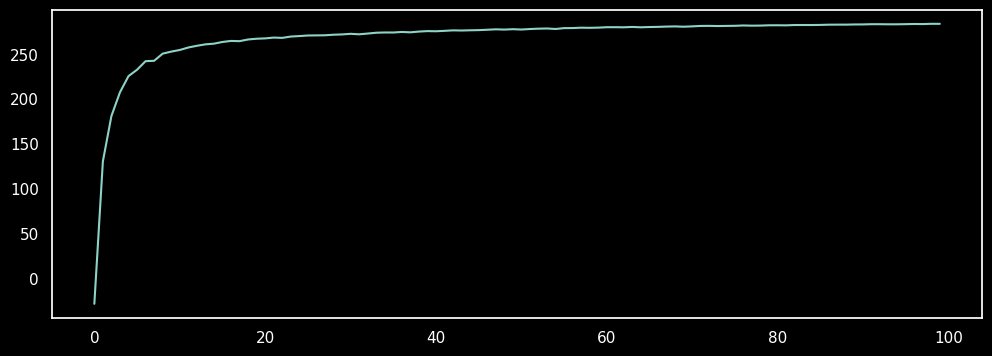

In [24]:
pyro.clear_param_store()
vae3 = VAEST(784, 16, context=10).cuda()

svi3 = SVI(vae3.model, vae3.guide, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

elbo = []
for epoch in (bar := tqdm(range(100))):
    losses = []

    for x, l in trainloader:
        x = x.flatten(-3).cuda()
        context = one_hot(l, 10).cuda()

        losses.append(svi3.step(x, context))

    losses = torch.tensor(losses)
    elbo.append( - losses.sum().item() / len(trainset))
    bar.set_postfix(loss=elbo[-1])

plt.figure(figsize=(12, 4))
plt.plot(elbo)

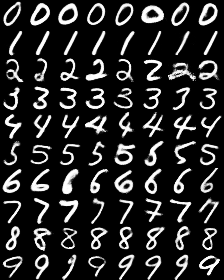

In [25]:
xs = []
for c in one_hot(torch.arange(10), 10):
    z = vae3.prior(c.cuda()).sample((8,))
    x = vae3.decoder(z).reshape(-1, 28, 28)
    xs.append(x)

xs = torch.stack(xs)

to_pil_image(xs.movedim(1, 2).reshape(28 * 10, -1))

In [26]:
get_test_accuracy(svi3, cutoff=10_000)

np.float64(0.9559)

Lets test a variant where amortized posterior does not depend on class label.

100%|██████████| 100/100 [11:37<00:00,  6.97s/it, loss=283]


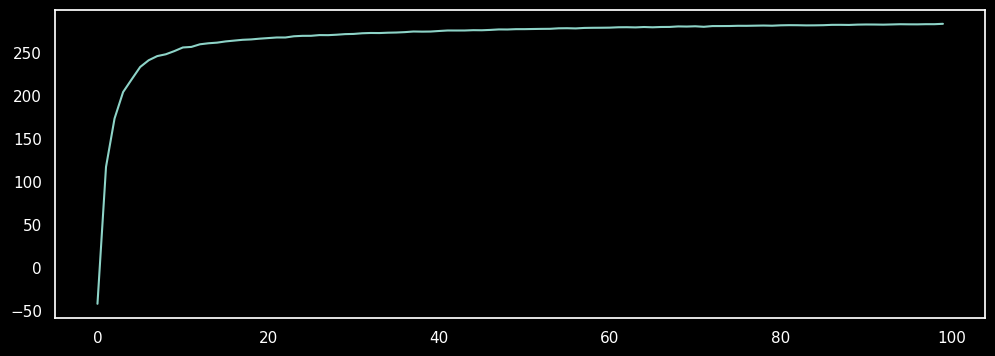

In [16]:
pyro.clear_param_store()

svi4 = SVI(vae4.model, vae4.guide, AdamW({'lr': 1e-3, 'weight_decay': 1e-4}), loss=Trace_ELBO())

elbo = []
for epoch in (bar := tqdm(range(100))):
    losses = []

    for x, l in trainloader:
        x = x.flatten(-3).cuda()
        context = one_hot(l, 10).cuda()

        losses.append(svi4.step(x, context))

    losses = torch.tensor(losses)
    elbo.append( - losses.sum().item() / len(trainset))
    bar.set_postfix(loss=elbo[-1])

plt.figure(figsize=(12, 4))
plt.plot(elbo)

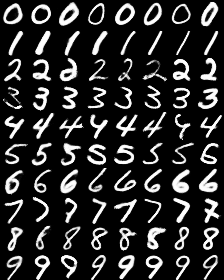

In [17]:
xs = []
for c in one_hot(torch.arange(10), 10):
    z = vae4.prior(c.cuda()).sample((8,))
    x = vae4.decoder(z).reshape(-1, 28, 28)
    xs.append(x)

xs = torch.stack(xs)

to_pil_image(xs.movedim(1, 2).reshape(28 * 10, -1))

In [19]:
get_test_accuracy(svi4, cutoff=10_000)

np.float64(0.8629)